# Proof-of-Concept MC-Dropout Emulator

This notebook trains a 4-parameter MC-dropout emulator for the binned kSZ angular power spectrum. The model predicts $\ln(D_\ell)$, then repeated dropout-enabled forward passes are used to estimate a predictive mean and uncertainty.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rc("figure", figsize=(6, 4), dpi=150)

from reionemu import (
    DataLoaderConfig,
    FitConfig,
    MCDropoutEmulator,
    fit,
    load_training_arrays,
    make_dataloaders,
    mean_relative_error,
    rmse,
)

## File Paths

The condensed v6 simulation dataset is constructed with $Y = \ln(D_\ell)$.

In [2]:
H5_PATH = Path("../data/processed/condensed_v6.h5").resolve()
CKPT_DIR = Path("../checkpoints/poc_mc_dropout").resolve()
MODEL_PATH = CKPT_DIR / "model.pt"
NORM_PATH = CKPT_DIR / "norm"

## Define Configs

`N_MC_EVAL` controls how many stochastic passes are used during validation inside `fit`. `N_MC_PLOT` controls how many stochastic passes are used later for final metrics and plots.

In [3]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

dlcfg = DataLoaderConfig(
    batch_size=32,
    seed=42,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=False,
)

fitcfg = FitConfig(
    epochs=200,
    device=str(device),
    early_stopping_patience=50,
    gradient_clipping=None,
)

model_config = {
    "input_dim": 4,
    "output_dim": 5,
    "hidden_dim": 20,
    "num_hidden_layers": 2,
    "activation": "relu",
    "dropout_rate": 0.1,
}

N_MC_EVAL = 25
N_MC_PLOT = 200

device

device(type='mps')

## Prepare Data and Model

The model trains normally with dropout active during `model.train()`. The Bayesian-style behavior comes from keeping dropout active during repeated inference passes.

In [4]:
loaders, norms, ell = make_dataloaders(
    H5_PATH,
    split={"train": 0.8, "val": 0.2},
    config=dlcfg,
)

model = MCDropoutEmulator(**model_config)
lossfn = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

model

MCDropoutEmulator(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=20, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=20, out_features=20, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=20, out_features=5, bias=True)
  )
)

## Train Model

`evaluate_mc_metrics` computes validation loss and metrics on the MC predictive mean. It also records `val_mean_predictive_std`, a compact epoch-level uncertainty summary.

In [5]:
history = fit(
    model,
    loaders["train"],
    loaders["val"],
    optimizer,
    lossfn,
    config=fitcfg,
    metrics={"rmse": rmse, "relative_error": mean_relative_error},
    evaluation="evaluate_mc_metrics",
    n_mc_samples=N_MC_EVAL,
)

Epoch 001: train=0.293437, val=0.274725, rmse=0.519173, relative_error=4.608781, predictive_std=0.046091
Epoch 002: train=0.232334, val=0.219028, rmse=0.462949, relative_error=4.884958, predictive_std=0.057637
Epoch 003: train=0.186307, val=0.157521, rmse=0.392280, relative_error=4.719261, predictive_std=0.076031
Epoch 004: train=0.126783, val=0.089441, rmse=0.295094, relative_error=3.264560, predictive_std=0.102795
Epoch 005: train=0.073812, val=0.044168, rmse=0.207128, relative_error=3.150298, predictive_std=0.125955
Epoch 006: train=0.051447, val=0.026241, rmse=0.159582, relative_error=3.684661, predictive_std=0.133105
Epoch 007: train=0.040450, val=0.020837, rmse=0.142978, relative_error=3.262778, predictive_std=0.131071
Epoch 008: train=0.037084, val=0.016876, rmse=0.128874, relative_error=2.673827, predictive_std=0.132966
Epoch 009: train=0.031775, val=0.014999, rmse=0.121150, relative_error=2.329294, predictive_std=0.131367
Epoch 010: train=0.033296, val=0.013985, rmse=0.117532,

## Training Curves

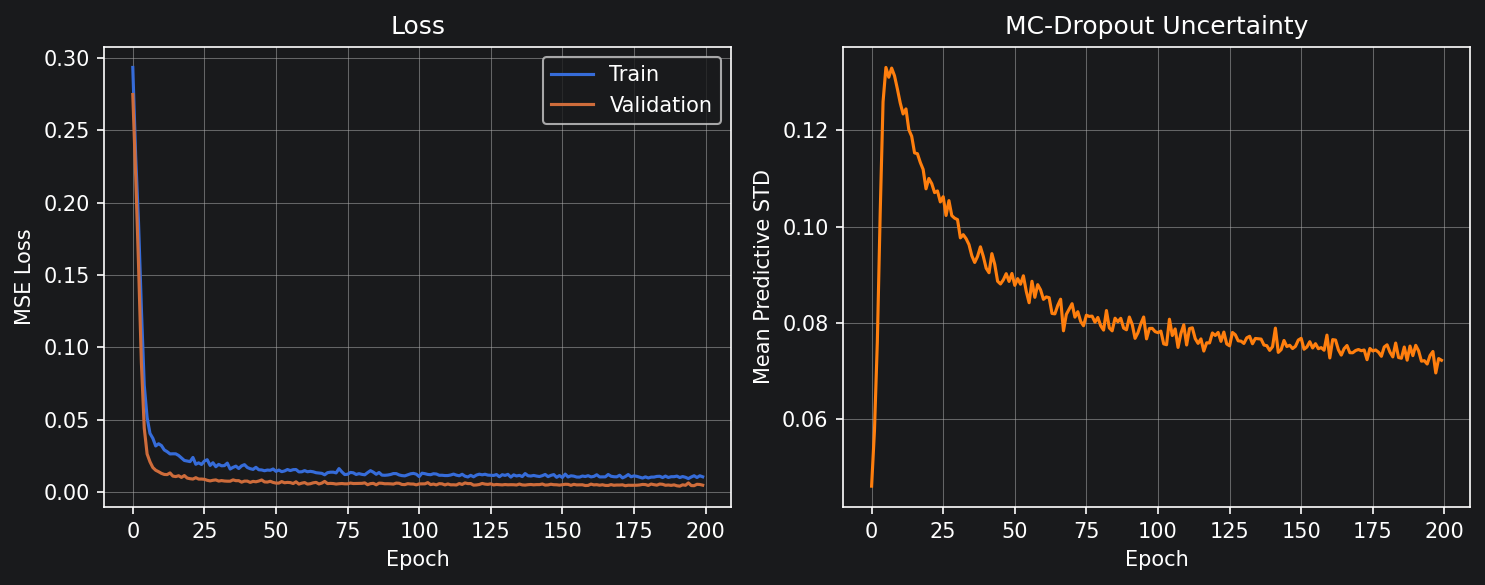

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(history["train_loss"], label="Train")
ax[0].plot(history["val_loss"], label="Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE Loss")
ax[0].set_title("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history["val_mean_predictive_std"], color="tab:orange")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean Predictive STD")
ax[1].set_title("MC-Dropout Uncertainty")
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Save Model and Normalization

In [7]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_config": model_config,
        "normalize_X": dlcfg.normalize_X,
        "normalize_Y": dlcfg.normalize_Y,
    },
    MODEL_PATH,
)
print(f"Model saved to {MODEL_PATH}")

NORM_PATH.mkdir(parents=True, exist_ok=True)
if norms["X"] is not None:
    np.save(NORM_PATH / "X_mean.npy", norms["X"].mean)
    np.save(NORM_PATH / "X_std.npy", norms["X"].std)
if norms["Y"] is not None:
    np.save(NORM_PATH / "Y_mean.npy", norms["Y"].mean)
    np.save(NORM_PATH / "Y_std.npy", norms["Y"].std)
np.save(NORM_PATH / "ell.npy", np.asarray(ell))
print(f"Normalizers saved to {NORM_PATH}")

Model saved to /Users/robertxpearce/Desktop/reionization-emulator/checkpoints/poc_mc_dropout/model.pt
Normalizers saved to /Users/robertxpearce/Desktop/reionization-emulator/checkpoints/poc_mc_dropout/norm


## Load Model and Normalization

This reload section checks that the saved checkpoint is enough to reconstruct the same MC-dropout model later.

In [8]:
checkpoint = torch.load(MODEL_PATH, map_location=device)

model = MCDropoutEmulator(**checkpoint["model_config"]).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

normalize_X = checkpoint["normalize_X"]
normalize_Y = checkpoint["normalize_Y"]

X_mean = np.load(NORM_PATH / "X_mean.npy") if normalize_X else None
X_std = np.load(NORM_PATH / "X_std.npy") if normalize_X else None
Y_mean = np.load(NORM_PATH / "Y_mean.npy") if normalize_Y else None
Y_std = np.load(NORM_PATH / "Y_std.npy") if normalize_Y else None
ell = np.load(NORM_PATH / "ell.npy")

model.eval()

MCDropoutEmulator(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=20, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=20, out_features=20, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=20, out_features=5, bias=True)
  )
)

## Define MC-Dropout Predict Function

This helper returns unreduced prediction arrays for plotting. It computes mean and standard deviation in physical $D_\ell$ space by exponentiating each sampled log prediction before aggregation.

In [9]:
def enable_dropout_only(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.train()


def predict_mc(
    params,
    model,
    X_mean=None,
    X_std=None,
    Y_mean=None,
    Y_std=None,
    *,
    normalize_X=True,
    normalize_Y=False,
    n_mc_samples=200,
):
    params = np.asarray(params, dtype=np.float32)
    squeeze = params.ndim == 1
    if squeeze:
        params = params[None, :]

    if normalize_X:
        params = (params - X_mean) / X_std

    xb = torch.from_numpy(params.astype(np.float32)).to(device)

    model.eval()
    enable_dropout_only(model)
    with torch.no_grad():
        samples = torch.stack([model(xb) for _ in range(n_mc_samples)], dim=0)

    samples_log = samples.cpu().numpy()
    if normalize_Y:
        samples_log = samples_log * Y_std + Y_mean

    samples_dl = np.exp(samples_log)
    pred_mean = samples_dl.mean(axis=0)
    pred_std = samples_dl.std(axis=0, ddof=1)

    if squeeze:
        return pred_mean[0], pred_std[0], samples_dl[:, 0, :]
    return pred_mean, pred_std, samples_dl

## Error and Uncertainty Metrics

The point-prediction metrics use the MC predictive mean.

In [10]:
X, Y, ell = load_training_arrays(H5_PATH)

pred_mean, pred_std, _ = predict_mc(
    X,
    model,
    X_mean,
    X_std,
    Y_mean,
    Y_std,
    normalize_X=normalize_X,
    normalize_Y=normalize_Y,
    n_mc_samples=N_MC_PLOT,
)

true = np.exp(Y)
errors = np.abs((pred_mean - true) / true)

mse = np.mean((pred_mean - true) ** 2)
mae = np.mean(np.abs(pred_mean - true))
percent_err = np.mean(errors) * 100
bin_percent_err = np.mean(errors, axis=0) * 100
mean_predictive_std = np.mean(pred_std)
coverage_1sigma = np.mean(np.abs(pred_mean - true) <= pred_std) * 100
coverage_2sigma = np.mean(np.abs(pred_mean - true) <= 2.0 * pred_std) * 100

flat_idx = np.argmax(errors)
i, b = np.unravel_index(flat_idx, errors.shape)

print("Mean Squared Error (MSE):\t", mse)
print("Mean Absolute Error (MAE):\t", mae)
print("Mean % Error:\t\t\t", percent_err)
print("Mean Predictive STD:\t\t", mean_predictive_std)
print("1-Sigma Coverage:\t\t", coverage_1sigma)
print("2-Sigma Coverage:\t\t", coverage_2sigma)
print()
print("Max % Error:\t\t\t", np.max(errors) * 100)
print("Mean % Error Per ell Bin:\t", bin_percent_err)
print()
print("Worst Case Sim:\t", i)
print("Worst Case Bin:\t", b)
print("True Dl:\t", true[i, b])
print("Pred Dl:\t", pred_mean[i, b])
print("Pred STD:\t", pred_std[i, b])
print("% Error:\t", errors[i, b] * 100)

Mean Squared Error (MSE):	 0.0041218335
Mean Absolute Error (MAE):	 0.045688402
Mean % Error:			 5.005716
Mean Predictive STD:		 0.065723166
1-Sigma Coverage:		 73.74000000000001
2-Sigma Coverage:		 94.42

Max % Error:			 30.749172
Mean % Error Per ell Bin:	 [5.885147  4.8106194 4.670355  4.733835  4.928618 ]

Worst Case Sim:	 724
Worst Case Bin:	 4
True Dl:	 0.24513768
Pred Dl:	 0.32051548
Pred STD:	 0.06284497
% Error:	 30.749172


## Isolate One Simulation

In [11]:
sim_idx = 0

params = X[sim_idx]
true_dl = np.exp(Y[sim_idx])
pred_dl, pred_dl_std, _ = predict_mc(
    params,
    model,
    X_mean,
    X_std,
    Y_mean,
    Y_std,
    normalize_X=normalize_X,
    normalize_Y=normalize_Y,
    n_mc_samples=N_MC_PLOT,
)

print(f"Params:\t\t {params}")
print()
print(f"True:\t\t {true_dl}")
print(f"Predicted:\t {pred_dl}")
print(f"STD:\t\t {pred_dl_std}")

Params:		 [7.3246355  0.48715696 0.25348133 0.71027094]

True:		 [1.4497963  1.1481824  0.8139568  0.66767186 0.66289914]
Predicted:	 [1.4478971 1.1672701 0.8441882 0.6775392 0.6628916]
STD:		 [0.07776351 0.06502499 0.05479267 0.04892108 0.05000848]


## True vs Predicted $D_\ell$ With MC-Dropout Uncertainty

Sim Index:		0
Params:			[7.3246355  0.48715696 0.25348133 0.71027094]
True Dl:		[1.4497963  1.1481824  0.8139568  0.66767186 0.66289914]
Predicted Dl:	[1.4521811  1.1720018  0.84824914 0.6811577  0.66660804]
Pred STD:		[0.0814335  0.07095258 0.05947899 0.05256198 0.05320571]
% Error:		[0.16449082 2.0745351  4.213042   2.019832   0.55949676]


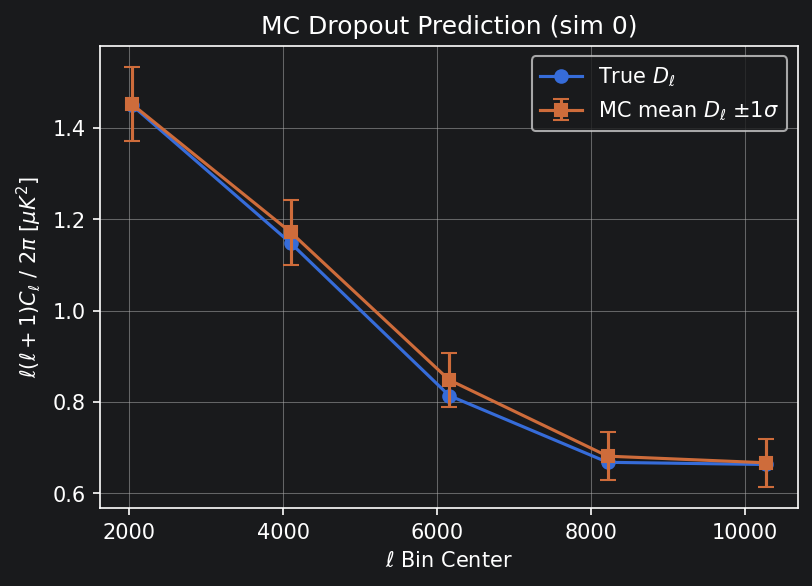

In [12]:
def plot_sim(sim_idx):
    params = X[sim_idx]
    true_dl = np.exp(Y[sim_idx])
    pred_dl, pred_std, _ = predict_mc(
        params,
        model,
        X_mean,
        X_std,
        Y_mean,
        Y_std,
        normalize_X=normalize_X,
        normalize_Y=normalize_Y,
        n_mc_samples=N_MC_PLOT,
    )

    pct_err = 100.0 * (pred_dl - true_dl) / true_dl

    print(f"Sim Index:\t\t{sim_idx}")
    print(f"Params:\t\t\t{params}")
    print(f"True Dl:\t\t{true_dl}")
    print(f"Predicted Dl:\t{pred_dl}")
    print(f"Pred STD:\t\t{pred_std}")
    print(f"% Error:\t\t{pct_err}")

    plt.plot(ell, true_dl, marker="o", label=r"True $D_\ell$")
    plt.errorbar(
        ell,
        pred_dl,
        yerr=pred_std,
        marker="s",
        capsize=4,
        linestyle="-",
        label=r"MC mean $D_\ell$ $\pm 1\sigma$",
    )
    plt.xlabel(r"$\ell$ Bin Center")
    plt.ylabel(r"$\ell (\ell + 1)C_{\ell}$ / $2 \pi$ [$\mu K^2$]")
    plt.title(f"MC Dropout Prediction (sim {sim_idx})")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_sim(0)